# Úkol 3 – Komplexní evaluace

**Předmět:** Úvod do strojového učení 
**Autor:** Ondřej Janeček  

Cílem notebooku je navázat na předchozí úkoly a provést komplexní porovnání modelů pro predikci inflace v České republice. Notebook vychází z již připravené datové pipeline (`dataprocessing.ipynb`) a benchmarku (`benchmark.ipynb`).

Predikovanou proměnnou je inflace v následujícím kvartálu, tedy `target = infl_cz(t+1)`. Úloha je proto formulována jako **regresní problém**.

Neuronové sítě nejsou zahrnuty, protože jsou podle zadání z tohoto srovnání výslovně vyjmuty.

## 1. Import knihoven

Použité modely odpovídají modelům probíraným v předmětu: baseline model, lineární modely, stromové modely, SVM a KNN


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Načtení připravených dat

Data byla připravena v notebooku `dataprocessing.ipynb`. Tento notebook již vytvořil soubory `data/train.csv`, `data/validation.csv` a `data/test.csv`.

Rozdělení je časové, nikoliv náhodné. 

In [2]:
train = pd.read_csv("data/train.csv", parse_dates=["date"], index_col="date")
valid = pd.read_csv("data/validation.csv", parse_dates=["date"], index_col="date")
test = pd.read_csv("data/test.csv", parse_dates=["date"], index_col="date")

print("Train:", train.shape, train.index.min(), "až", train.index.max())
print("Validation:", valid.shape, valid.index.min(), "až", valid.index.max())
print("Test:", test.shape, test.index.min(), "až", test.index.max())

display(train.head())
display(test.head())

Train: (75, 7) 1997-06-30 00:00:00 až 2015-12-31 00:00:00
Validation: (20, 7) 2016-03-31 00:00:00 až 2020-12-31 00:00:00
Test: (19, 7) 2021-03-31 00:00:00 až 2025-09-30 00:00:00


,infl_cz,infl_de,rate,oil,gdp_growth,target,baseline
date,,,,,,,
1997-06-30,6.271031,1.364923,19.670382,18.045156,6.774390,9.243244,6.923669
1997-09-30,9.243244,1.580334,15.476838,18.506230,0.070889,9.595555,6.271031
1997-12-31,9.595555,1.494587,16.463697,18.762381,-0.063139,12.295729,9.243244
1998-03-31,12.295729,0.565313,16.011698,14.104444,-7.800293,11.644553,9.595555
1998-06-30,11.644553,0.868908,15.611397,13.310984,7.621212,8.669770,12.295729


,infl_cz,infl_de,rate,oil,gdp_growth,target,baseline
date,,,,,,,
2021-03-31,2.168025,1.736903,0.360000,61.038730,-6.983761,2.760375,2.700482
2021-06-30,2.760375,2.161203,0.401003,68.981803,8.199434,3.273442,2.168025
2021-09-30,3.273442,3.518535,0.912949,73.509077,1.615258,5.019695,2.760375
2021-12-31,5.019695,5.448859,2.830846,79.609062,1.124233,10.225083,3.273442
2022-03-31,10.225083,6.080975,4.587923,100.872344,-6.164302,15.029760,5.019695


## 3. Kontrola sloupců a definice proměnných

Používám stejné vstupní proměnné jako v původním benchmarku:

- `infl_de` – inflace v Německu
- `rate` – úroková sazba
- `oil` – cena ropy
- `gdp_growth` – růst HDP ČR

Cílová proměnná je `target`.

In [3]:
print("Sloupce v train datasetu:")
print(train.columns.tolist())

features = ["infl_de", "rate", "oil", "gdp_growth"]
target = "target"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

print("\nPoužité vstupní proměnné:", features)
print("Cílová proměnná:", target)

Sloupce v train datasetu:
['infl_cz', 'infl_de', 'rate', 'oil', 'gdp_growth', 'target', 'baseline']

Použité vstupní proměnné: ['infl_de', 'rate', 'oil', 'gdp_growth']
Cílová proměnná: target


## 4. Poznámka k baseline modelu

V datech už je připravený sloupec `baseline`. 


In [4]:
print("Ukázka původní baseline z datasetu:")
display(test[["infl_cz", "target", "baseline"]].head())

Ukázka původní baseline z datasetu:


,infl_cz,target,baseline
date,,,
2021-03-31,2.168025,2.760375,2.700482
2021-06-30,2.760375,3.273442,2.168025
2021-09-30,3.273442,5.019695,2.760375
2021-12-31,5.019695,10.225083,3.273442
2022-03-31,10.225083,15.029760,5.019695


## 5. Pomocná funkce pro výpočet metrik

Protože jde o regresní úlohu, používám metriky MAE, RMSE a R².

In [5]:
def regression_metrics(y_true, y_pred):
    """Vrátí základní metriky pro regresní model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 6. Definice modelů

SVM a KNN jsou citlivé na měřítko proměnných, proto jsou vloženy do pipeline se standardizací. Standardizaci používám i u penalizovaných lineárních modelů Ridge, Lasso a ElasticNet.

Stromové modely standardizaci nepotřebují.

In [6]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=10000))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
    ]),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf"))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ])
}

models

{'LinearRegression': LinearRegression(),
 'Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())]),
 'Lasso': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', Lasso(alpha=0.01, max_iter=10000))]),
 'ElasticNet': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', ElasticNet(alpha=0.01, max_iter=10000))]),
 'DecisionTree': DecisionTreeRegressor(random_state=42),
 'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42),
 'GradientBoosting': GradientBoostingRegressor(random_state=42),
 'SVR': Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR())]),
 'KNN': Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor())])}

## 7. Trénink a vyhodnocení modelů

Modely trénuji pouze na trénovací sadě. Validační sada slouží k průběžnému porovnání a testovací sada je použita pro finální vyhodnocení.

In [7]:
results = []
predictions_test = {}

# Baseline z HW2 – naivní časová predikce
baseline_train_pred = train["baseline"]
baseline_valid_pred = valid["baseline"]
baseline_test_pred = test["baseline"]

train_mae, train_rmse, train_r2 = regression_metrics(y_train, baseline_train_pred)
valid_mae, valid_rmse, valid_r2 = regression_metrics(y_valid, baseline_valid_pred)
test_mae, test_rmse, test_r2 = regression_metrics(y_test, baseline_test_pred)

results.append({
    "model": "Baseline_HW2",
    "train_MAE": train_mae,
    "valid_MAE": valid_mae,
    "test_MAE": test_mae,
    "train_RMSE": train_rmse,
    "valid_RMSE": valid_rmse,
    "test_RMSE": test_rmse,
    "train_R2": train_r2,
    "valid_R2": valid_r2,
    "test_R2": test_r2,
    "overfit_gap_RMSE": test_rmse - train_rmse
})

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    y_test_pred = model.predict(X_test)

    predictions_test[name] = y_test_pred

    train_mae, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
    valid_mae, valid_rmse, valid_r2 = regression_metrics(y_valid, y_valid_pred)
    test_mae, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

    results.append({
        "model": name,
        "train_MAE": train_mae,
        "valid_MAE": valid_mae,
        "test_MAE": test_mae,
        "train_RMSE": train_rmse,
        "valid_RMSE": valid_rmse,
        "test_RMSE": test_rmse,
        "train_R2": train_r2,
        "valid_R2": valid_r2,
        "test_R2": test_r2,
        "overfit_gap_RMSE": test_rmse - train_rmse
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("test_RMSE").reset_index(drop=True)

results_df

,model,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE,train_R2,valid_R2,test_R2,overfit_gap_RMSE
0,Ridge,0.866864,1.785561,2.244964,1.118136,2.191834,2.568989,0.828573,-5.804872,0.801067,1.450853
1,ElasticNet,0.866532,1.801942,2.249231,1.117516,2.209089,2.574773,0.828763,-5.912430,0.800170,1.457256
2,Lasso,0.866061,1.808068,2.251391,1.117401,2.214883,2.577132,0.828799,-5.948738,0.799804,1.459731
3,LinearRegression,0.867390,1.828040,2.254608,1.117120,2.239225,2.584594,0.828885,-6.102312,0.798643,1.467474
4,Baseline_HW2,1.448224,0.576288,3.242240,1.953782,0.762672,4.579724,0.476591,0.176090,0.367791,2.625943
5,KNN,0.911192,1.152897,3.880527,1.244627,1.403499,5.669840,0.787594,-1.790157,0.031000,4.425214
6,GradientBoosting,0.133104,1.360131,4.634921,0.167495,1.585215,5.960059,0.996153,-2.559431,-0.070738,5.792564
7,RandomForest,0.348628,1.326391,4.501314,0.453960,1.551384,5.980613,0.971743,-2.409127,-0.078136,5.526653
8,DecisionTree,0.000000,1.307543,5.401599,0.000000,1.566385,6.808103,1.000000,-2.475375,-0.397123,6.808103
9,SVR,0.980587,1.165099,5.060639,1.514915,1.399771,7.200461,0.685322,-1.775352,-0.562798,5.685545


Úloha je formulována jako regresní problém, proto jsou pro hodnocení použity metriky RMSE, MAE a R².

## 9. Přehled výsledků na testovací sadě

Následující tabulka je hlavním finálním porovnáním modelů. Řazení je podle `test_RMSE`, tedy podle chyby na testovací sadě.

In [8]:
final_table = results_df[[
    "model", "test_MAE", "test_RMSE", "test_R2", "train_RMSE", "overfit_gap_RMSE"
]].copy()

final_table = final_table.sort_values("test_RMSE").reset_index(drop=True)
final_table

,model,test_MAE,test_RMSE,test_R2,train_RMSE,overfit_gap_RMSE
0,Ridge,2.244964,2.568989,0.801067,1.118136,1.450853
1,ElasticNet,2.249231,2.574773,0.800170,1.117516,1.457256
2,Lasso,2.251391,2.577132,0.799804,1.117401,1.459731
3,LinearRegression,2.254608,2.584594,0.798643,1.117120,1.467474
4,Baseline_HW2,3.242240,4.579724,0.367791,1.953782,2.625943
5,KNN,3.880527,5.669840,0.031000,1.244627,4.425214
6,GradientBoosting,4.634921,5.960059,-0.070738,0.167495,5.792564
7,RandomForest,4.501314,5.980613,-0.078136,0.453960,5.526653
8,DecisionTree,5.401599,6.808103,-0.397123,0.000000,6.808103
9,SVR,5.060639,7.200461,-0.562798,1.514915,5.685545


## 10. Grafické porovnání podle RMSE

In [9]:
print(results_df.head())

              model  train_MAE  valid_MAE  test_MAE  train_RMSE  valid_RMSE  test_RMSE  train_R2  valid_R2   test_R2  \
0             Ridge   0.866864   1.785561  2.244964    1.118136    2.191834   2.568989  0.828573 -5.804872  0.801067   
1        ElasticNet   0.866532   1.801942  2.249231    1.117516    2.209089   2.574773  0.828763 -5.912430  0.800170   
2             Lasso   0.866061   1.808068  2.251391    1.117401    2.214883   2.577132  0.828799 -5.948738  0.799804   
3  LinearRegression   0.867390   1.828040  2.254608    1.117120    2.239225   2.584594  0.828885 -6.102312  0.798643   
4      Baseline_HW2   1.448224   0.576288  3.242240    1.953782    0.762672   4.579724  0.476591  0.176090  0.367791   

   overfit_gap_RMSE  
0          1.450853  
1          1.457256  
2          1.459731  
3          1.467474  
4          2.625943  


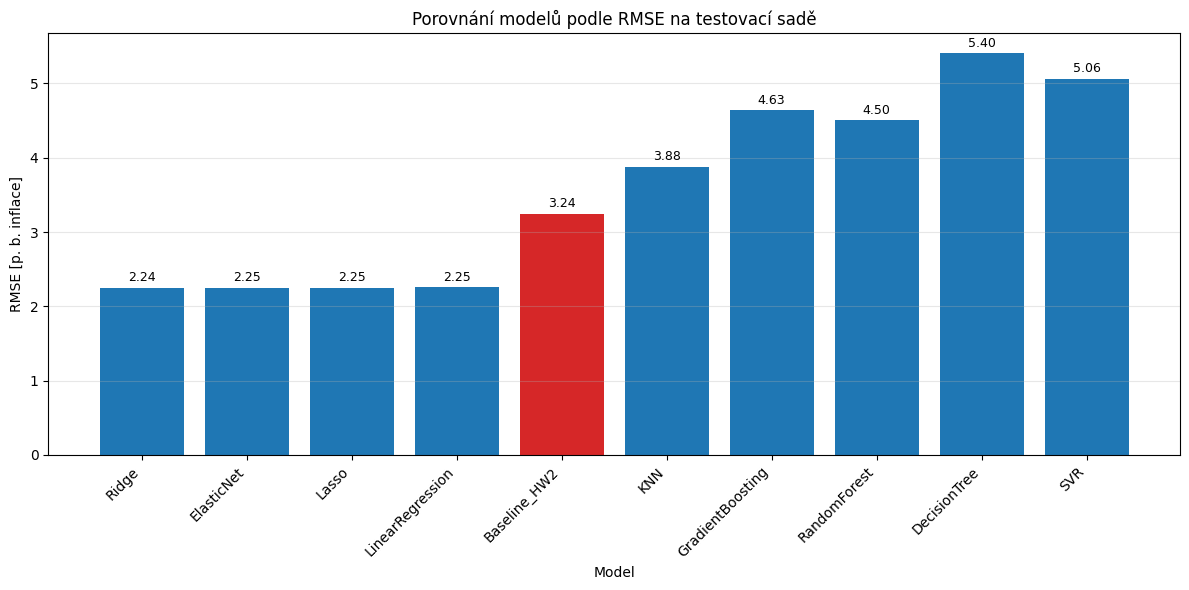

In [10]:
plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if model == "Baseline_HW2"
    else "tab:blue"
    for model in final_table["model"]
]
bars = plt.bar(
    final_table["model"],
    final_table["test_MAE"],
    color=colors
)


plt.title("Porovnání modelů podle RMSE na testovací sadě")
plt.ylabel("RMSE [p. b. inflace]")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# hodnoty nad sloupci
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

## 11. Grafické porovnání podle MAE

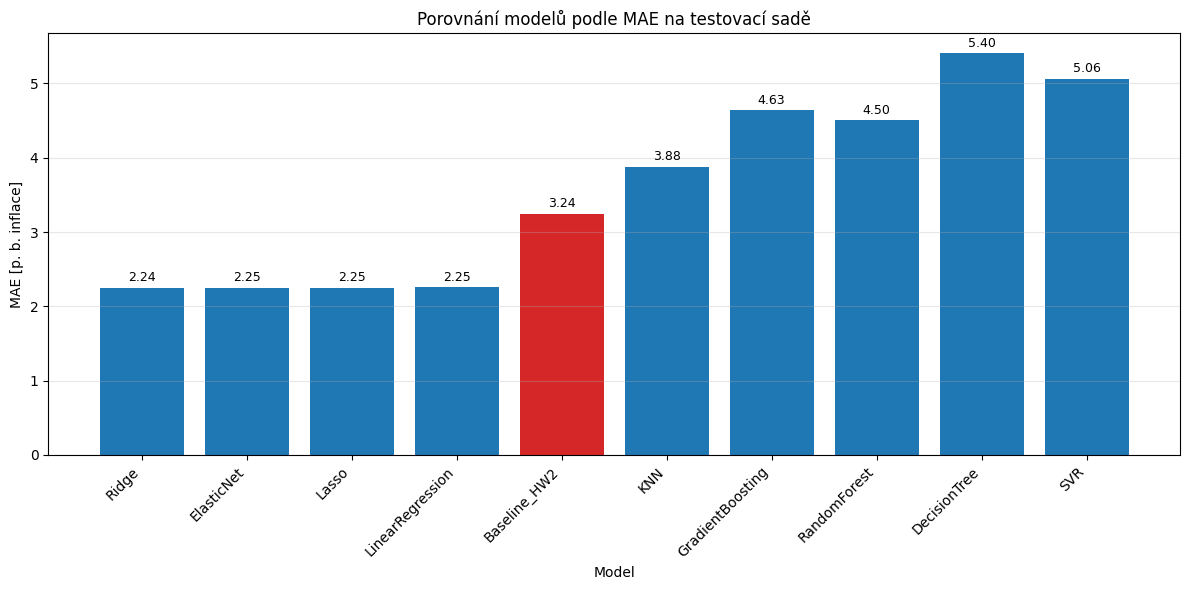

In [11]:
plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if model == "Baseline_HW2"
    else "tab:blue"
    for model in final_table["model"]
]
bars = plt.bar(
    final_table["model"],
    final_table["test_MAE"],
    color=colors
)

plt.title("Porovnání modelů podle MAE na testovací sadě")
plt.ylabel("MAE [p. b. inflace]")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# hodnoty nad sloupci
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 12. Kontrola možného přeučení

Přeučení se může projevit tak, že model má velmi nízkou chybu na trénovacích datech, ale výrazně horší chybu na testovacích datech.

In [12]:
overfit_table = results_df[[
    "model", "train_RMSE", "test_RMSE", "overfit_gap_RMSE"
]].sort_values("overfit_gap_RMSE", ascending=False)

overfit_table

,model,train_RMSE,test_RMSE,overfit_gap_RMSE
8,DecisionTree,0.000000,6.808103,6.808103
6,GradientBoosting,0.167495,5.960059,5.792564
9,SVR,1.514915,7.200461,5.685545
7,RandomForest,0.453960,5.980613,5.526653
5,KNN,1.244627,5.669840,4.425214
4,Baseline_HW2,1.953782,4.579724,2.625943
3,LinearRegression,1.117120,2.584594,1.467474
2,Lasso,1.117401,2.577132,1.459731
1,ElasticNet,1.117516,2.574773,1.457256
0,Ridge,1.118136,2.568989,1.450853


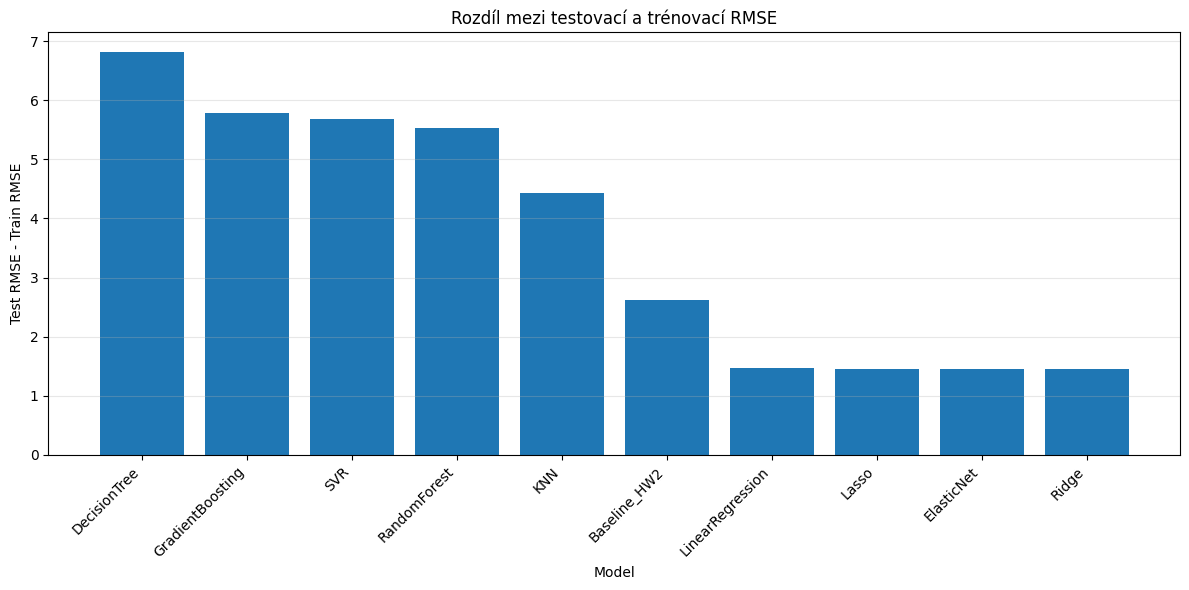

In [13]:
plot_overfit = overfit_table.sort_values("overfit_gap_RMSE", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_overfit["model"], plot_overfit["overfit_gap_RMSE"])
plt.title("Rozdíl mezi testovací a trénovací RMSE")
plt.ylabel("Test RMSE - Train RMSE")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Porovnání skutečných a predikovaných hodnot

V grafu porovnávám skutečnou inflaci v následujícím kvartálu s predikcí nejlepšího modelu podle testovací RMSE.

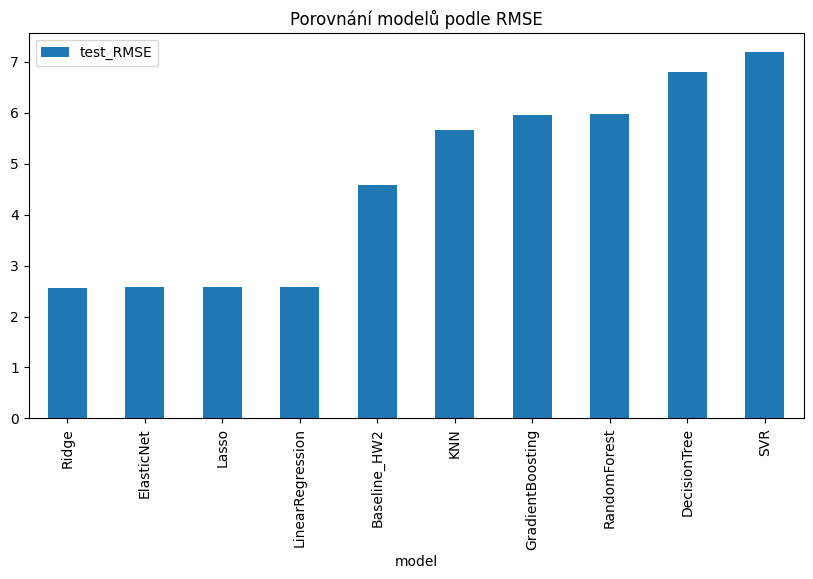

In [14]:
results_df.sort_values("test_RMSE").plot(
    x="model",
    y="test_RMSE",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle RMSE"
)
plt.show()

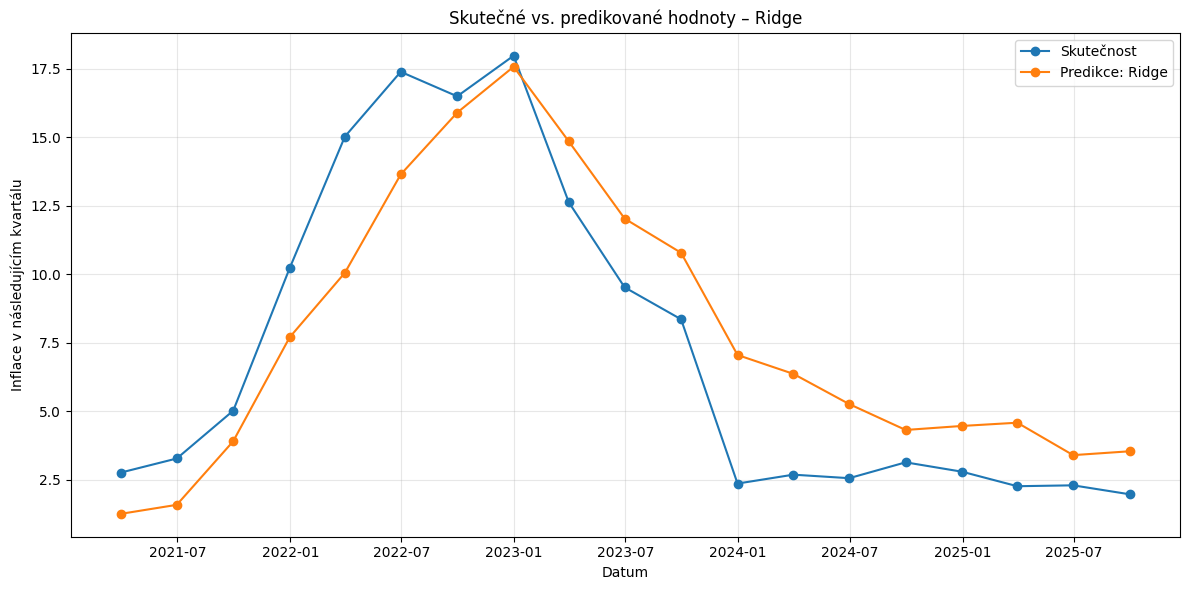

Nejlepší model podle testovací RMSE: Ridge


In [15]:
best_model_name = results_df.sort_values("test_RMSE").iloc[0]["model"]

if best_model_name == "Baseline_HW2":
    best_model_pred = baseline_test_pred
else:
    best_model_pred = predictions_test[best_model_name]

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, marker="o", label="Skutečnost")
plt.plot(y_test.index, best_model_pred, marker="o", label=f"Predikce: {best_model_name}")
plt.title(f"Skutečné vs. predikované hodnoty – {best_model_name}")
plt.ylabel("Inflace v následujícím kvartálu")
plt.xlabel("Datum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Nejlepší model podle testovací RMSE:", best_model_name)

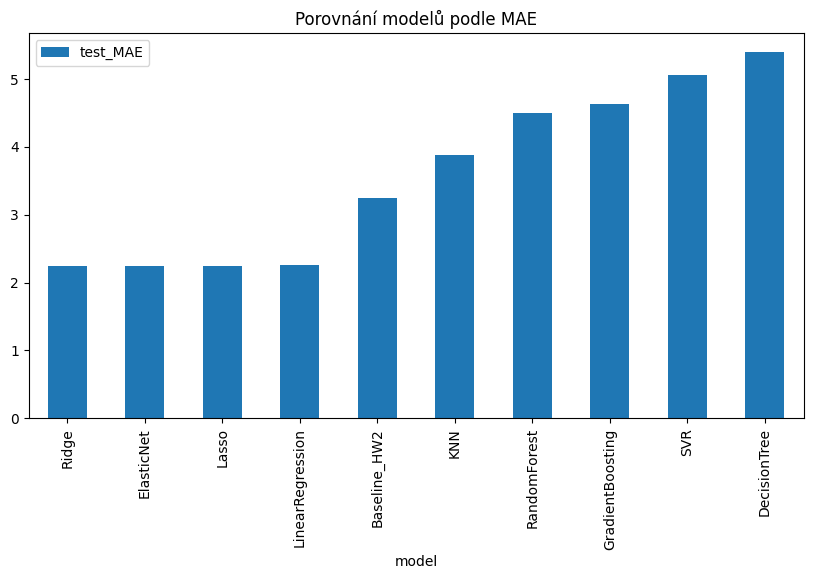

In [16]:
results_df.sort_values("test_MAE").plot(
    x="model",
    y="test_MAE",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle MAE"
)
plt.show()

Výsledky podle metriky MAE potvrzují závěry získané z RMSE. Nejnižší průměrné absolutní chyby dosáhly lineární modely Ridge, Elastic Net, Lasso a klasická lineární regrese. Rozdíly mezi těmito modely jsou velmi malé, což naznačuje, že regularizace nemá na daném datasetu zásadní vliv. Stromové modely a SVR vykazují výrazně vyšší chyby. To naznačuje, že vztahy mezi použitými makroekonomickými proměnnými a inflací jsou převážně lineární a jednodušší modely zde poskytují lepší generalizační schopnost než složitější nelineární přístupy.

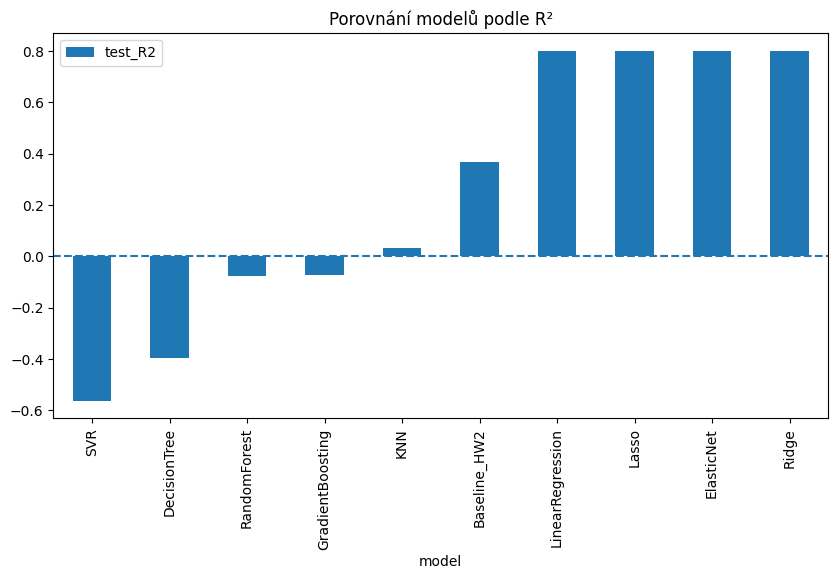

In [17]:
results_df.sort_values("test_R2").plot(
    x="model",
    y="test_R2",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle R²"
)
plt.axhline(y=0, linestyle="--")
plt.show()

Metrika R² potvrzuje závěry získané z RMSE a MAE. Nejlepších výsledků dosáhly lineární modely Ridge, Elastic Net, Lasso a klasická lineární regrese, které vysvětlují přibližně 80 % variability cílové proměnné. Naopak stromové modely, SVR a DummyRegressor vykazují záporné hodnoty R², což znamená, že jejich predikce jsou horší než jednoduchá predikce průměrnou hodnotou. Výsledky naznačují, že vztah mezi použitými makroekonomickými ukazateli a budoucí inflací je převážně lineární a nevyžaduje složité nelineární modely.

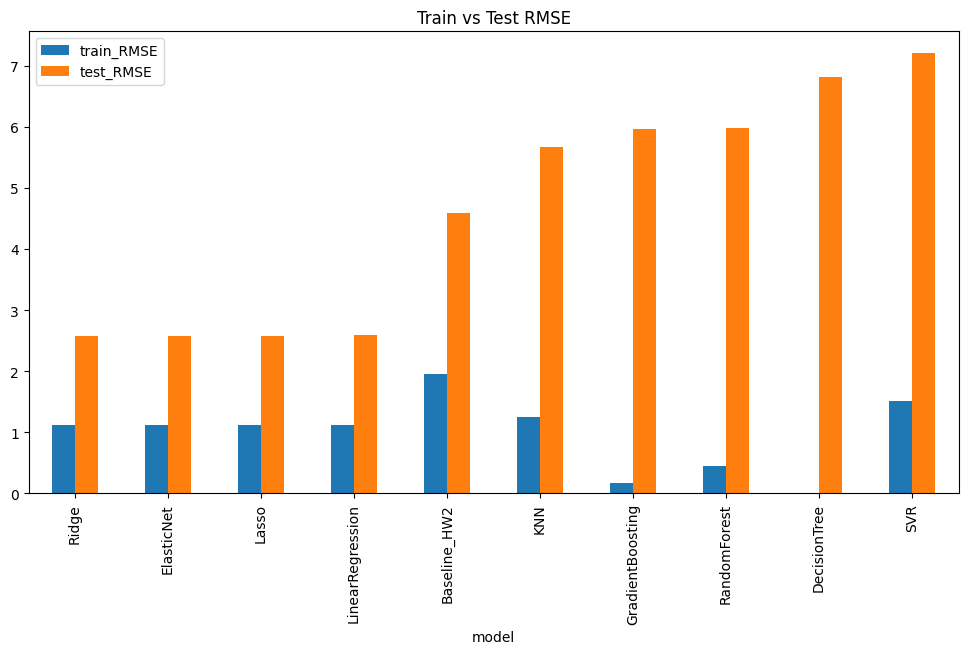

In [18]:
results_df.plot(
    x="model",
    y=["train_RMSE","test_RMSE"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Train vs Test RMSE")
plt.show()

Graf porovnávající trénovací a testovací RMSE ukazuje výrazné rozdíly mezi jednotlivými modely. Lineární modely Ridge, Lasso, Elastic Net a klasická lineární regrese vykazují relativně malý rozdíl mezi trénovací a testovací chybou, což naznačuje dobrou schopnost generalizace. Naopak stromové modely vykazují výrazné známky přeučení. Nejvýraznější přeučení bylo pozorováno u modelu Decision Tree, který dosahoval téměř nulové chyby na trénovacích datech, avšak velmi vysoké chyby na datech testovacích. Podobné chování bylo pozorováno také u Random Forest a Gradient Boosting. Tyto výsledky naznačují, že velikost datasetu není dostatečná pro efektivní využití složitějších nelineárních modelů a jednodušší lineární modely poskytují stabilnější výsledky.

## 14. Porovnání s baseline modelem z HW2

Zde počítám rozdíl mezi nejlepším modelem a naivní časovou baseline z HW2. Tato baseline vychází ze setrvačnosti inflace.

In [19]:
best_row = results_df.sort_values("test_RMSE").iloc[0]
baseline_row = results_df[results_df["model"] == "Baseline_HW2"].iloc[0]

absolute_improvement = baseline_row["test_RMSE"] - best_row["test_RMSE"]
relative_improvement = absolute_improvement / baseline_row["test_RMSE"] * 100

print("Nejlepší model:", best_row["model"])
print("RMSE nejlepšího modelu:", round(best_row["test_RMSE"], 4))
print("RMSE baseline z HW2:", round(baseline_row["test_RMSE"], 4))
print("Absolutní zlepšení RMSE:", round(absolute_improvement, 4))
print("Relativní zlepšení RMSE v %:", round(relative_improvement, 2))

Nejlepší model: Ridge
RMSE nejlepšího modelu: 2.569
RMSE baseline z HW2: 4.5797
Absolutní zlepšení RMSE: 2.0107
Relativní zlepšení RMSE v %: 43.91


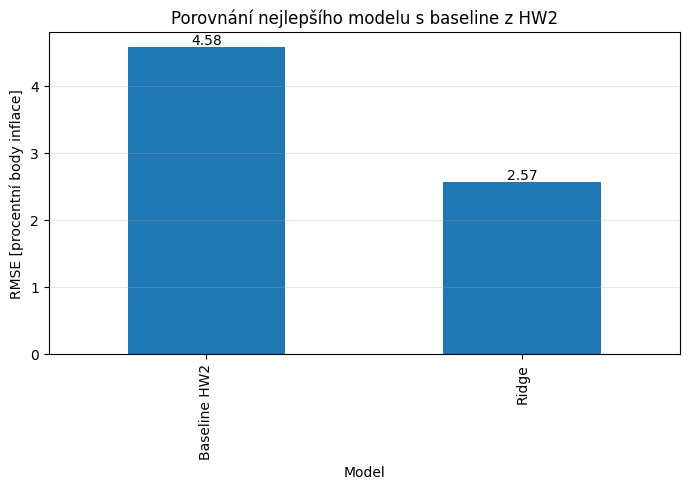

In [20]:
comparison = pd.DataFrame({
    "Model": ["Baseline HW2", best_row["model"]],
    "RMSE": [
        baseline_row["test_RMSE"],
        best_row["test_RMSE"]
    ]
})

ax = comparison.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(7,5),
    legend=False,
    title="Porovnání nejlepšího modelu s baseline z HW2"
)

plt.ylabel("RMSE [procentní body inflace]")
plt.xlabel("Model")
plt.grid(axis="y", alpha=0.3)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

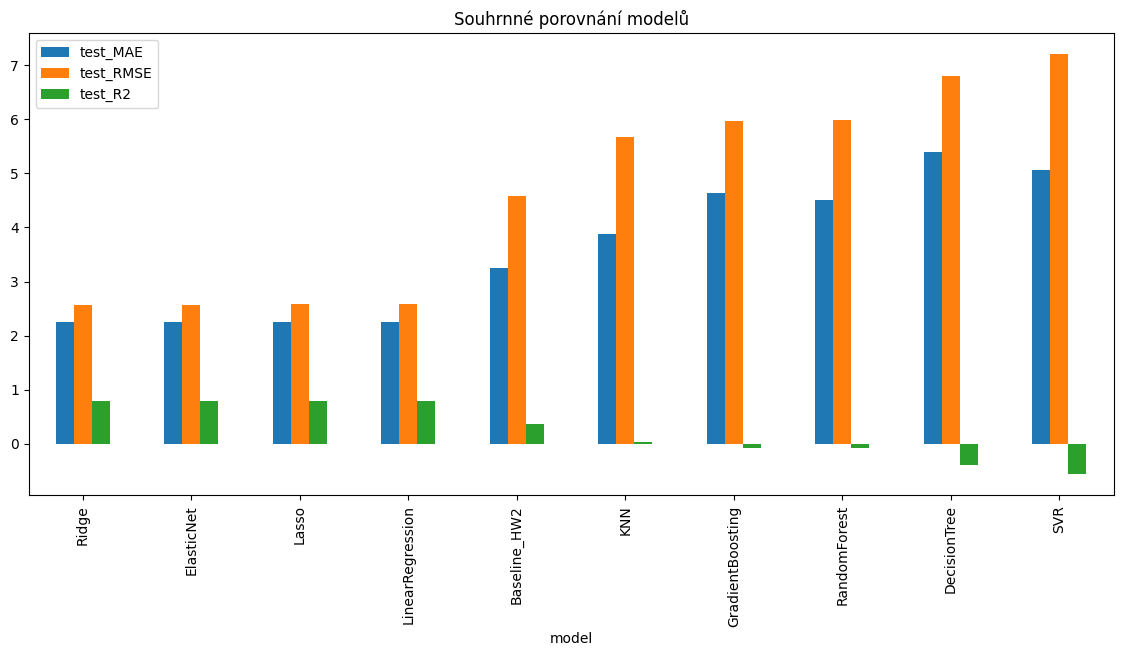

In [21]:
metrics_plot = results_df.set_index("model")[
    ["test_MAE","test_RMSE","test_R2"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Souhrnné porovnání modelů")
plt.show()

## 15. Diskuze výsledků
Cílem úkolu bylo porovnat výkonnost různých metod strojového učení při predikci inflace v České republice a zhodnotit jejich schopnost překonat jednoduchý baseline model. Jako baseline byla použita naivní časová predikce vytvořená již v předchozím úkolu (HW2), která předpokládá, že budoucí hodnota inflace bude stejná jako poslední známá hodnota.

Baseline model z HW2 dosáhl RMSE 4,58, zatímco nejlepší model Ridge Regression dosáhl RMSE 2,57. To představuje snížení predikční chyby přibližně o 44 %. Rozdíl lze považovat za významný, protože ukazuje, že využití dodatečných makroekonomických proměnných přináší oproti samotné setrvačnosti inflace podstatně přesnější predikce.

Nejlepších výsledků dosáhl model Ridge Regression, který na testovacích datech dosáhl hodnoty RMSE 2,57, MAE 2,24 a koeficientu determinace R² = 0,80. Velmi podobných výsledků dosáhly také modely ElasticNet, Lasso a klasická Lineární regrese. Rozdíly mezi těmito modely jsou minimální, což naznačuje, že vztahy mezi použitými makroekonomickými proměnnými a budoucí inflací jsou převážně lineární a nevyžadují složitější nelineární modelování.

Také ostatní lineární modely (Lasso, Elastic Net a klasická lineární regrese) dosáhly velmi podobných výsledků jako Ridge Regression a rovněž výrazně překonaly baseline model z HW2.

Naopak stromové modely (Decision Tree, Random Forest a Gradient Boosting) dosáhly výrazně horších výsledků. U všech těchto modelů je patrný velký rozdíl mezi chybou na trénovacích a testovacích datech. Například Decision Tree dosáhl nulové chyby na trénovacích datech (RMSE = 0), ale velmi vysoké chyby na testovacích datech (RMSE = 6,81). To je typický projev přeučení (overfittingu), kdy se model příliš přizpůsobí trénovacím datům a ztrácí schopnost zobecnění.

Podobný problém lze pozorovat také u modelů Random Forest a Gradient Boosting, které sice dosahují velmi nízkých chyb na trénovacích datech, ale jejich výkonnost na testovacích datech je výrazně horší než u lineárních modelů. Příčinou může být relativně malý počet pozorování v datovém souboru, který neumožňuje těmto složitějším modelům spolehlivě odhadnout obecné vztahy.

Model KNN dosáhl středních výsledků (RMSE 5,67), avšak nepřekonal baseline model. KNN je založen na podobnosti jednotlivých pozorování a u makroekonomických časových řad nemusí být tento princip vhodný, protože ekonomické vztahy se v čase mění a nejsou dány pouze vzdáleností mezi pozorováními.

Nejhorších výsledků dosáhl model SVR, který vykázal zápornou hodnotu R² (-0,56). Záporné R² znamená, že model predikuje hůře než jednoduchá predikce průměrné hodnoty cílové proměnné. Výsledky naznačují, že zvolená konfigurace SVR nebyla pro tento problém vhodná.

Výsledky ukazují, že pro daný problém a rozsah dat představují nejlepší kompromis mezi přesností a schopností generalizace regularizované lineární modely. Přestože byly testovány i pokročilejší algoritmy strojového učení, jejich vyšší komplexita nevedla ke zlepšení výsledků. Studie tak potvrzuje, že při práci s ekonomickými časovými řadami nemusí být složitější model vždy lepší než dobře navržený lineární přístup.

Celkově lze konstatovat, že pro daný datový soubor a použitou úlohu se jako nejvhodnější ukázaly lineární modely. Ty nejen dosáhly nejnižších hodnot chybových metrik, ale zároveň vykazovaly nejmenší známky přeučení. Výsledky potvrzují, že při práci s makroekonomickými ukazateli a omezeným množstvím historických dat nemusí být složitější metody strojového učení automaticky lepší než jednodušší lineární přístupy.